<a href="https://colab.research.google.com/github/harshsu7/Linear-Regression/blob/main/SVM_%26_RF_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

In [17]:
df = pd.read_csv(r'/content/WineQT.csv')
df.sample(n=5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
446,8.7,0.54,0.26,2.5,0.097,7.0,31.0,0.99760,3.27,0.60,9.3,6,630
757,8.0,0.62,0.33,2.7,0.088,16.0,37.0,0.99720,3.31,0.58,10.7,6,1073
1054,5.3,0.47,0.11,2.2,0.048,16.0,89.0,0.99182,3.54,0.88,13.6,7,1477
240,12.5,0.28,0.54,2.3,0.082,12.0,29.0,0.99970,3.11,1.36,9.8,7,339
1042,6.8,0.59,0.10,1.7,0.063,34.0,53.0,0.99580,3.41,0.67,9.7,5,1464


In [18]:
df.shape

(1143, 13)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [20]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


Text(0.5, 1.0, 'Wine Quality Distribution')

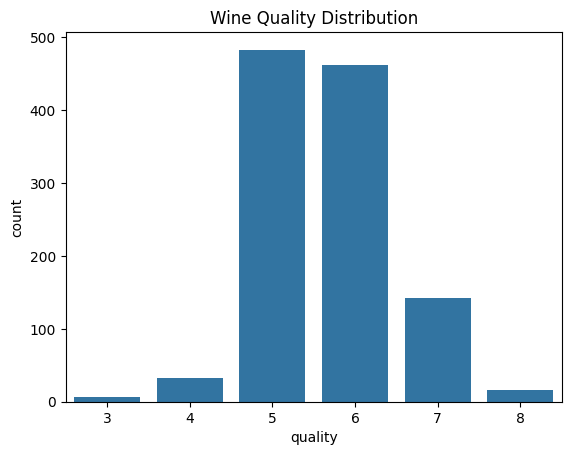

In [21]:
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Distribution")

Text(0.5, 1.0, 'Correlation Matrix')

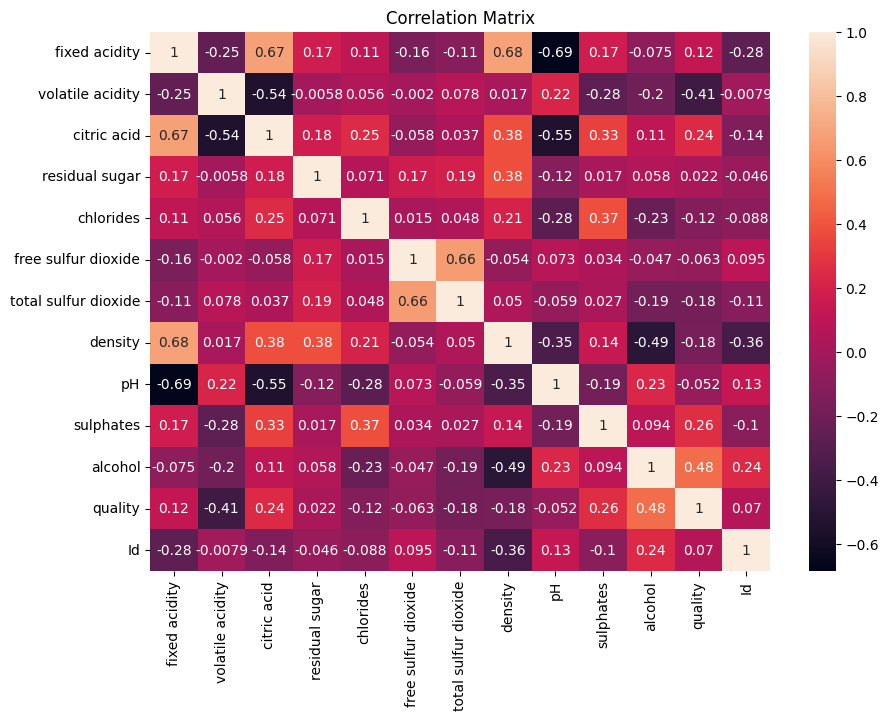

In [22]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")

In [23]:
df["quality"] = np.where(df["quality"] >= 7,1,0)

df["quality"].value_counts()

,count
quality,
0,984
1,159


In [24]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.925764192139738


In [28]:
svm = SVC(kernel="rbf", probability=True)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8995633187772926


In [29]:
rf_probs = rf.predict_proba(X_test)[:,1]

In [30]:
svm_probs = svm.predict_proba(X_test_scaled)[:,1]

In [31]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

rf_auc = auc(rf_fpr, rf_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

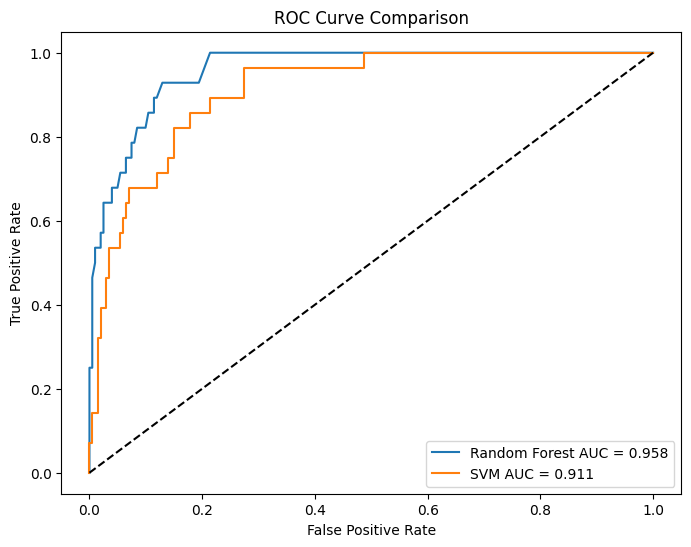

In [32]:
plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label="Random Forest AUC = %.3f" % rf_auc)
plt.plot(svm_fpr, svm_tpr, label="SVM AUC = %.3f" % svm_auc)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [33]:
results = pd.DataFrame({
    "Model": ["Random Forest","SVM"],
    "Accuracy":[rf_accuracy, svm_accuracy],
    "AUC":[rf_auc, svm_auc]
})

results

,Model,Accuracy,AUC
0,Random Forest,0.925764,0.957889
1,SVM,0.899563,0.911158


Text(0.5, 1.0, 'Feature Importance (Random Forest)')

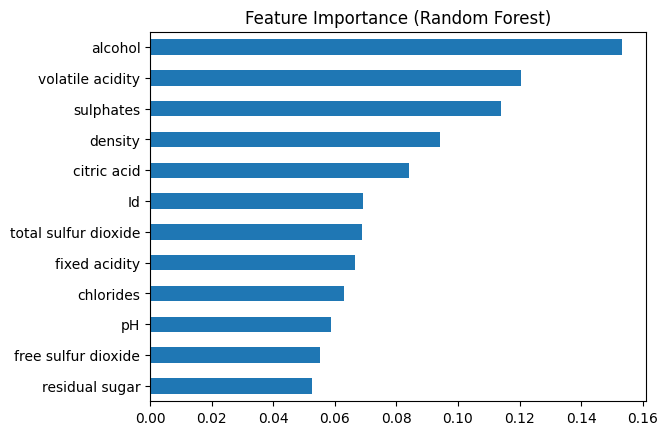

In [34]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")